# Reservoir computing clásico y cuántico en señal simple.

## Carga de librerías.

In [1]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

## Generación de la señal random.

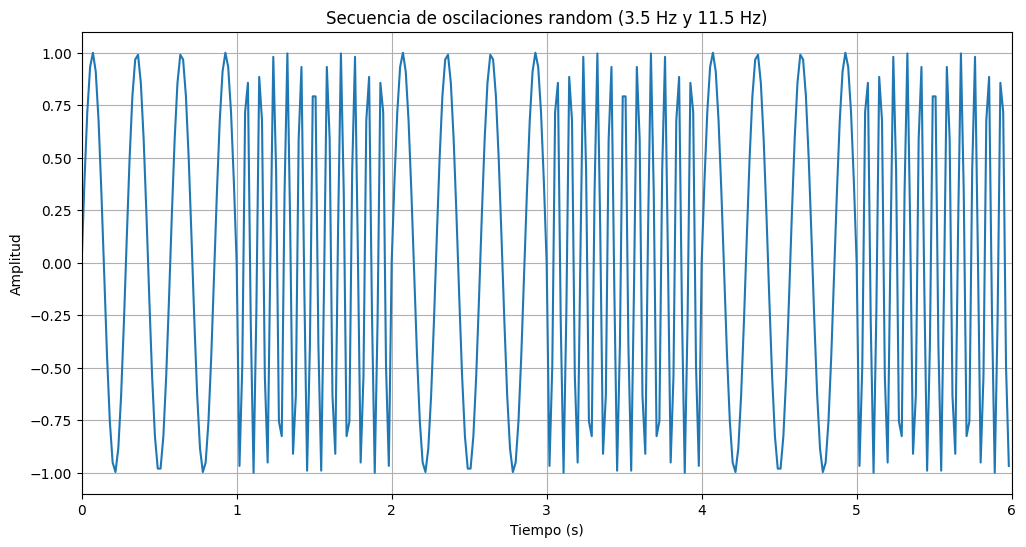

In [2]:
# Parámetros  
fs = 55            # Frecuencia de muestreo en Hz  
t_total = 6        # Duración total en segundos  
f1 = 3.5            # Frecuencia de la primera oscilación en Hz  
f2 = 11.5           # Frecuencia de la segunda oscilación en Hz  
duracion_segmento = 1  # Duración de cada segmento en segundos  
num_repeticiones = 6 # Número total de segmentos (3 de cada oscilacion) 

# vector de tiempo
t = np.arange(0, t_total, 1/fs) 

# Generamos las oscilaciones aleatorias   

amplitud = 1  # Amplitud aleatoria para la osc. 

# Inicializamos la secuencia  
secuencia = np.zeros_like(t)

# Llenar la secuencia con oscilaciones alternando  
for i in range(num_repeticiones):  
    if i % 2 == 0:  # Índices pares para la primera oscilación  
        start = i * duracion_segmento * fs  
        end = start + duracion_segmento * fs  
        secuencia[start:end] = amplitud  * np.sin(2 * np.pi * f1 * t[start:end])  
    else:  # Índices impares para la segunda oscilación  
        start = i * duracion_segmento * fs  
        end = start + duracion_segmento * fs  
        secuencia[start:end] = amplitud * np.sin(2 * np.pi * f2 * t[start:end])
# Graficar la señal  
plt.figure(figsize=(12, 6))  
plt.plot(t, secuencia)  
plt.title('Secuencia de oscilaciones random (3.5 Hz y 11.5 Hz)')  
plt.xlabel('Tiempo (s)')  
plt.ylabel('Amplitud')  
plt.xlim(0, t_total)  
plt.grid()  
plt.show()

## Implementación clásica.

In [12]:
# Parámetros
num_input_channels = 1      # Dimensionalidad de entrada (1 canal)
num_reservoir_neurons = 10  # Número de neuronas en el reservorio
num_readout_neurons = 1      # Número de neuronas de salida

num_training_samples = t.shape[0] # Número de muestras de entrenamiento

# Generar pesos de entrada al reservorio
input2res = np.random.randn(num_reservoir_neurons, num_input_channels)

# Generar pesos recurrentes del reservorio
res2res = np.random.randn(num_reservoir_neurons, num_reservoir_neurons)


# Generar pesos recurrentes del reservorio
res2res = np.random.randn(num_reservoir_neurons, num_reservoir_neurons)

# Normalizar las columnas de los pesos recurrentes
res2res = res2res / np.linalg.norm(res2res, axis=0)

# Sesgo del reservorio
input_bias = np.random.rand(num_reservoir_neurons, 1)

sec = secuencia.reshape(1, len(secuencia))


# Estados iniciales del reservorio
#reservoir_states = np.zeros((num_reservoir_neurons, num_training_samples + 1))
reservoir_states = np.random.randn(num_reservoir_neurons,num_training_samples + 1);

# Dinámicas del reservorio
for i in range(num_training_samples):
    reservoir_states[:, i + 1] = np.tanh(
        #(0.05 * input2res @ secuencia[i, np.newaxis]) +
        (0.05 * input2res @ sec[:, i]) +
        (0.95 * res2res @ reservoir_states[:, i]) +
        input_bias.flatten()
    )

# Extracción de la envolvente superior usando Hilbert transform
RS = reservoir_states - np.mean(reservoir_states,axis=1, keepdims=True)
print(RS.shape)
analytic_signal = hilbert(RS, axis=1)
amplitude_envelope = np.abs(analytic_signal)

print(analytic_signal.shape)
print(RS.shape)
print(amplitude_envelope.shape)

(10, 331)
(10, 331)
(10, 331)
(10, 331)


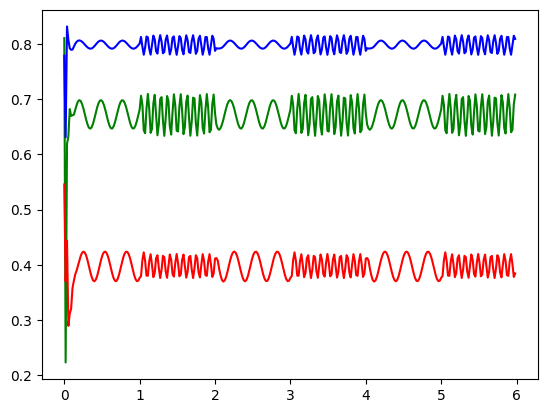

In [13]:
# estados puros del reservoir.
plt.plot(t, reservoir_states[0, 1:], color = 'green')
plt.plot(t, reservoir_states[1, 1:], color = 'red')
plt.plot(t, reservoir_states[2, 1:], color = 'blue')
plt.show()

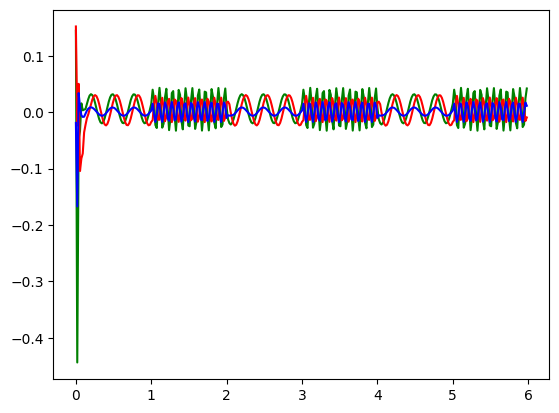

In [14]:
# estados centrados en el 0.
plt.plot(t, RS[0, 1:], color = 'green')
plt.plot(t, RS[1, 1:], color = 'red')
plt.plot(t, RS[2, 1:], color = 'blue')
plt.show()

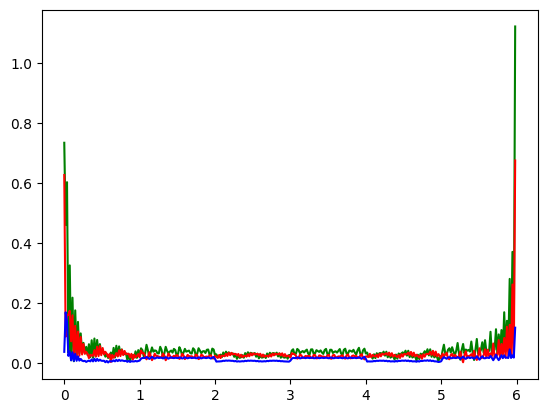

In [15]:
# envolvente de los estados.
plt.plot(t, amplitude_envelope[0, 1:], color = 'green')
plt.plot(t, amplitude_envelope[1, 1:], color = 'red')
plt.plot(t, amplitude_envelope[2, 1:], color = 'blue')
plt.show()

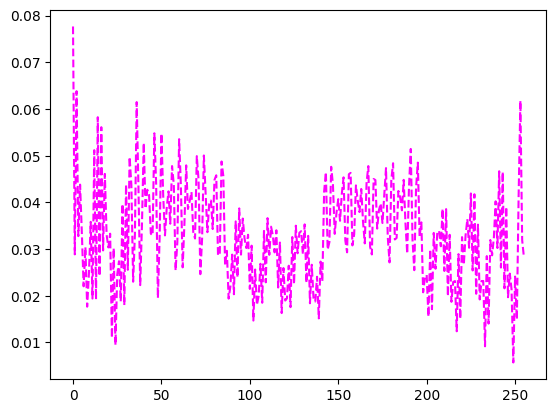

In [16]:
# Eliminamos los primeros 25 puntos para estabilizar el reservorio
stable_start = min(25, amplitude_envelope.shape[1])
input_sequence = amplitude_envelope[:, stable_start:-50]
plt.plot(input_sequence[0, :], linestyle="dashed", color = 'magenta')
plt.show()

In [17]:
# Agrupamiento (clustering)
num_clusters = 2  # Número de clústeres
kmeans = KMeans(n_clusters=num_clusters, random_state=42).fit(input_sequence.T)

# Resultados
idx = kmeans.labels_  # Etiquetas de los clústeres
C = kmeans.cluster_centers_  # Centroides de los clústeres

print("Centroides de los clústeres:")
print(C)
print(idx.shape)

Centroides de los clústeres:
[[0.02860555 0.02804569 0.00760817 0.01154722 0.10176672 0.04318214
  0.03288785 0.00833731 0.04665337 0.01431881]
 [0.03874558 0.02277972 0.0176853  0.01039227 0.06260681 0.02574072
  0.01398522 0.00670011 0.04092044 0.02285484]]
(256,)


In [18]:
# Agrupamiento con algoritmo GMM(Gaussian Mixture Model).

def clustering_gmm(input_sequence, n_components=2):  
    """  
    Función para realizar agrupamiento usando GMM.  

    Args:  
    - input_sequence: Array de entrada procesado para el agrupamiento.  
    - num_clusters: Número de estados cerebrales. Default es 2.  

    Returns:  
    - labels: Etiquetas de los clústeres asignados a cada muestra de entrada. 
    """
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    cluster_labels = gmm.fit_predict(input_sequence.T)
    return cluster_labels

idx_gmm = clustering_gmm(input_sequence)

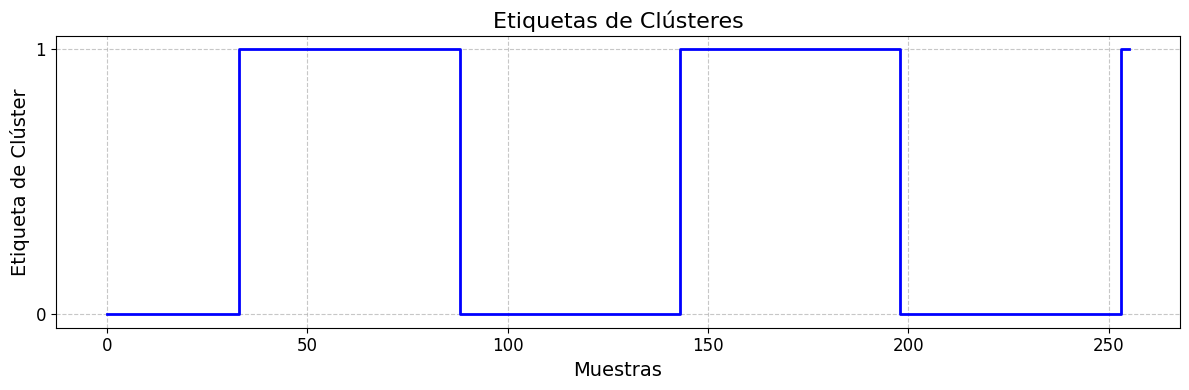

In [19]:
# Etiquetas con K-Means.
plt.figure(figsize=(12, 4))  
plt.step(range(input_sequence.shape[1]), idx, where='post', color='blue', linewidth=2) 
plt.title('Etiquetas de Clústeres', fontsize=16)
plt.xlabel('Muestras', fontsize=14)  
plt.ylabel('Etiqueta de Clúster', fontsize=14)  
plt.yticks(np.arange(num_clusters))  
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12)  
plt.grid(True, linestyle='--', alpha=0.7)
#plt.xlim(100, 200)  
plt.tight_layout() 
plt.show()

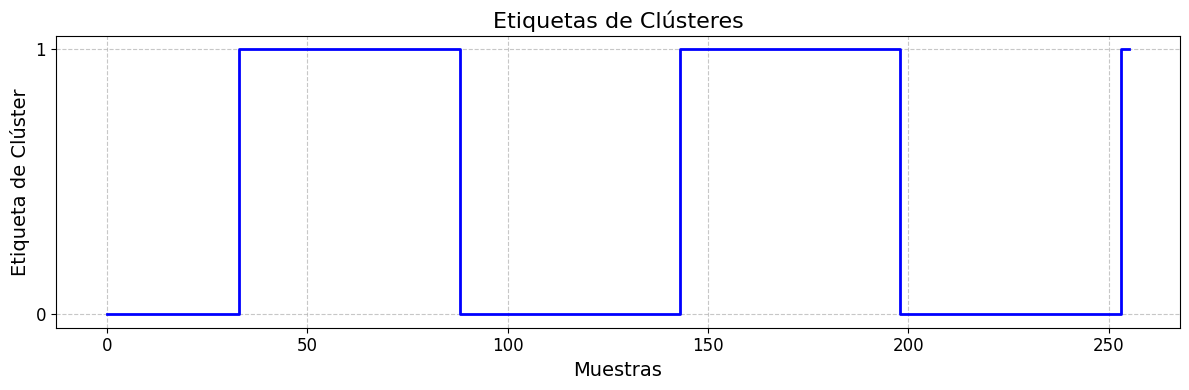

In [20]:
# Etiquetas con GMM.
plt.figure(figsize=(12, 4))  
plt.step(range(input_sequence.shape[1]), idx_gmm, where='post', color='blue', linewidth=2) 
plt.title('Etiquetas de Clústeres', fontsize=16)
plt.xlabel('Muestras', fontsize=14)  
plt.ylabel('Etiqueta de Clúster', fontsize=14)  
plt.yticks(np.arange(num_clusters))  
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12)  
plt.grid(True, linestyle='--', alpha=0.7)
#plt.xlim(100, 200)  
plt.tight_layout() 
plt.show()

## Implementación cuántica.

In [21]:
# Número de qubits (tamaño del reservoir cuántico)
num_qubits = 3
# Profundidad del circuito
num_layers = 1  

# Creamos un dispositivo cuántico.
dev = qml.device("default.qubit", wires=num_qubits)

In [22]:
# Definimos el Quantum Reservoir  
def quantum_reservoir(reservoir_weights):  
    """Quantum Reservoir con compuertas CNOT y rotaciones."""    
    for i in range(num_qubits):
         for j in range(num_qubits):
            # Rotación aleatoria en cada qubit  
            qml.RX(reservoir_weights[i,j], wires= i)
            # Entrelazamiento con el siguiente qubit (circular)  
            control_qubit = i 
            target_qubit = (i + 1) % num_qubits  
            qml.CNOT(wires=[control_qubit, target_qubit])

In [23]:
# Define Quantum Node
@qml.qnode(dev)
def quantum_echo_state_network(input_data, prev_output, weights_in, weights_rc, reservoir_weights):
    """Quantum Echo State Network (QESN)"""
    # Encode input and previous output into qubits
    for i in range(num_qubits):
        qml.RX(.05*weights_in[i] * input_data + .95*weights_rc[i] * prev_output[i], wires=i)
    
    # Evolve through the quantum reservoir
    quantum_reservoir(reservoir_weights)
    
    # Devolvemos un vector de probabilidades de los estados.
    return qml.probs(wires=range(num_qubits))

In [24]:
# Initialize parameters
weights_in = np.random.uniform(-np.pi, np.pi, num_qubits)
weights_rc = np.random.uniform(-np.pi, np.pi, num_qubits)
reservoir_weights = np.random.uniform(-np.pi, np.pi, (num_qubits, num_qubits))

sec = secuencia.reshape(1, len(secuencia))
input_series = sec
time_steps = input_series.shape[1]

# Run QESN
outputs = []
prev_output = np.zeros(num_qubits)  # Initial output

for t0 in range(time_steps):
    q_prob = quantum_echo_state_network(input_series[0, t0], prev_output, weights_in, weights_rc, reservoir_weights)

    final_output = np.tanh(q_prob) # usamos la tanh de los estados cuánticos(en probabilidades)

    # Almacenamos el resultado en la lista.
    outputs.append(final_output)
    prev_output = final_output  # Recurrent connection
    print(f"Step {t0}: {final_output}")

# Convertimos outputs a numpy array.
outputs = np.array(outputs)

Step 0: [0.30865665 0.16110213 0.00084626 0.03003979 0.02044699 0.02760198
 0.31098438 0.117291  ]
Step 1: [0.26399852 0.20547076 0.00063141 0.04005997 0.02510159 0.03961412
 0.26091257 0.14753397]
Step 2: [0.24634044 0.22343955 0.00143779 0.04379034 0.02431405 0.04356308
 0.24137777 0.16041358]
Step 3: [0.23656982 0.23253233 0.00203331 0.04661999 0.02395942 0.04637397
 0.23069282 0.16645477]
Step 4: [0.23284216 0.23613061 0.00230202 0.0473143  0.02391609 0.04706904
 0.22663962 0.1691727 ]
Step 5: [0.23490948 0.23483321 0.00217309 0.04559042 0.02417138 0.04542468
 0.22890176 0.16922095]
Step 6: [0.24211038 0.22906931 0.00172836 0.04177046 0.02473223 0.04174735
 0.2367589  0.16683425]
Step 7: [0.25301093 0.21970088 0.00116659 0.03661468 0.02560693 0.03673627
 0.24867091 0.16242125]
Step 8: [0.26559832 0.20816457 0.00067838 0.03113579 0.02671483 0.03132643
 0.26245122 0.15670278]
Step 9: [0.27771296 0.19635219 0.00035282 0.02632176 0.02785608 0.02645471
 0.27572311 0.15065445]
Step 10: [

In [25]:
outputs = outputs.T
outputs.shape

(8, 330)

(8, 330)


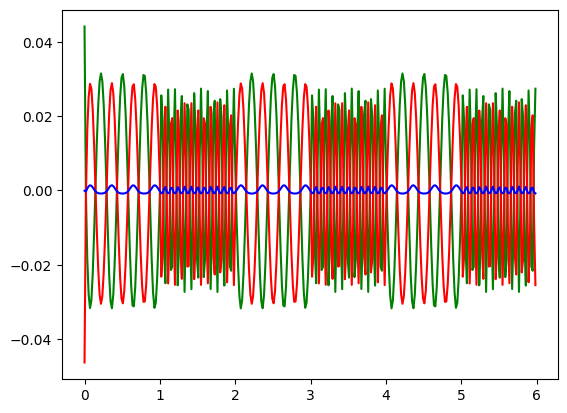

In [26]:
RS_cuantico2 = outputs - np.mean(outputs,axis=1, keepdims=True)
print(RS_cuantico2.shape)

plt.plot(t, RS_cuantico2[0, :], color = 'green')
plt.plot(t, RS_cuantico2[1, :], color = 'red')
plt.plot(t, RS_cuantico2[2, :], color = 'blue')
plt.show()

In [27]:
analytic_signal = hilbert(RS_cuantico2)
amplitude_envelope_cuant2 = np.abs(analytic_signal)
print(analytic_signal.shape)
print(amplitude_envelope_cuant2.shape)

(8, 330)
(8, 330)


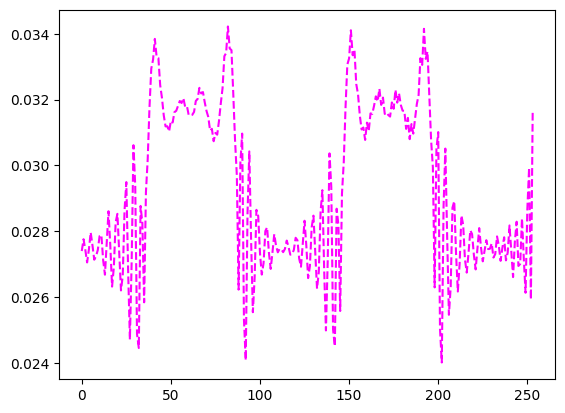

In [28]:
# Eliminamos primeros puntos del reservoir.
stable_start = min(75, amplitude_envelope_cuant2.shape[1])
input_sequence_cuant2 = amplitude_envelope_cuant2[:,stable_start:]
plt.plot(input_sequence_cuant2[0,1:], linestyle="dashed", color = 'magenta')
plt.show()

In [29]:
# Agrupamiento (clustering)
num_clusters = 2  # Número de clústeres
kmeans = KMeans(n_clusters=num_clusters, random_state=42).fit(input_sequence_cuant2.T)

# Resultados
idx_cuant = kmeans.labels_  # Etiquetas de los clústeres
C = kmeans.cluster_centers_  # Centroides de los clústeres

print("Centroides de los clústeres:")
print(C)
print(idx_cuant.shape)

Centroides de los clústeres:
[[0.03181042 0.02979653 0.00111462 0.01363263 0.00286457 0.01363098
  0.03482827 0.0150339 ]
 [0.0273167  0.02455865 0.00092056 0.01432535 0.00298478 0.01409806
  0.0298928  0.01069198]]
(255,)


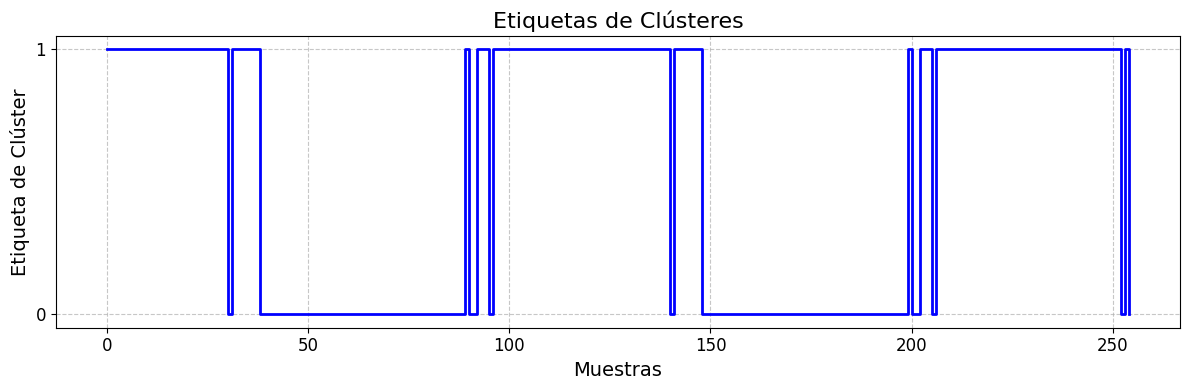

In [30]:
plt.figure(figsize=(12, 4))  
plt.step(range(input_sequence_cuant2.shape[1]), idx_cuant, where='post', color='blue', linewidth=2) 
plt.title('Etiquetas de Clústeres', fontsize=16)
plt.xlabel('Muestras', fontsize=14)  
plt.ylabel('Etiqueta de Clúster', fontsize=14)  
plt.yticks(np.arange(num_clusters))  
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12)  
plt.grid(True, linestyle='--', alpha=0.7)
#plt.xlim(100, 200)  
plt.tight_layout() 
plt.show()

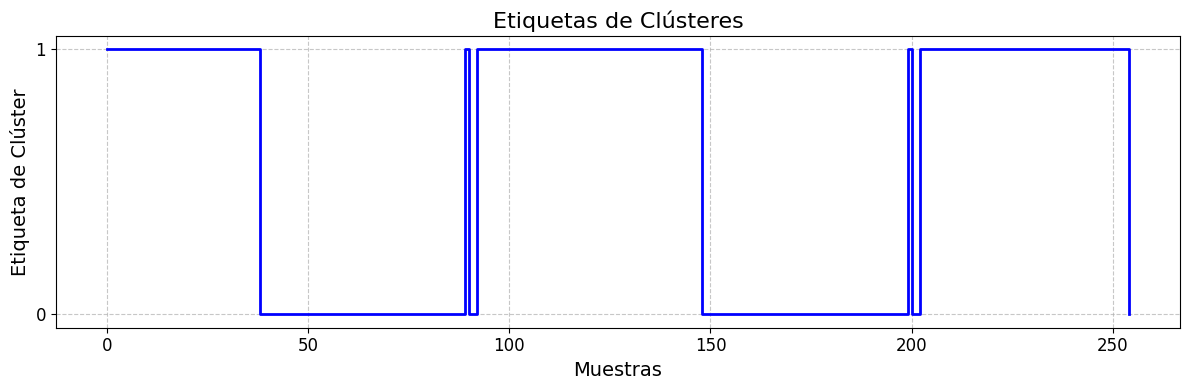

In [31]:
idx_gmm_cuant = clustering_gmm(input_sequence_cuant2)

plt.figure(figsize=(12, 4))  
plt.step(range(input_sequence_cuant2.shape[1]), idx_gmm_cuant, where='post', color='blue', linewidth=2) 
plt.title('Etiquetas de Clústeres', fontsize=16)
plt.xlabel('Muestras', fontsize=14)  
plt.ylabel('Etiqueta de Clúster', fontsize=14)  
plt.yticks(np.arange(num_clusters))  
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12)  
plt.grid(True, linestyle='--', alpha=0.7)
#plt.xlim(100, 200)  
plt.tight_layout() 
plt.show()

# Gráficos memoria.

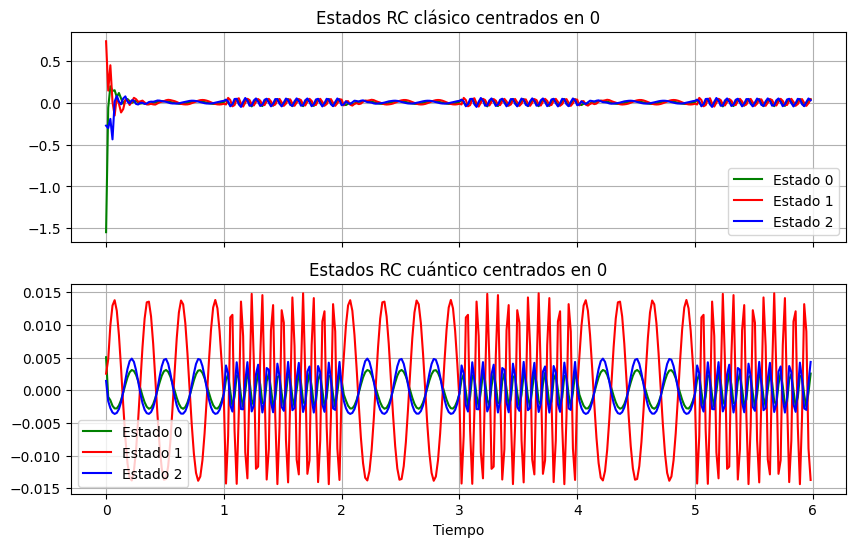

In [16]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

# Primer subplot: RS centrado en 0 (omitiendo la primera columna)
axs[0].plot(t, RS[0, 1:], color='green', label='Estado 0')
axs[0].plot(t, RS[1, 1:], color='red', label='Estado 1')
axs[0].plot(t, RS[2, 1:], color='blue', label='Estado 2')
axs[0].set_title("Estados RC clásico centrados en 0")
axs[0].legend()
axs[0].grid(True)

# Segundo subplot: RS_cuantico2 completo
axs[1].plot(t, RS_cuantico2[0, :], color='green', label='Estado 0')
axs[1].plot(t, RS_cuantico2[1, :], color='red', label='Estado 1')
axs[1].plot(t, RS_cuantico2[2, :], color='blue', label='Estado 2')
axs[1].set_title("Estados RC cuántico centrados en 0")
axs[1].set_xlabel("Tiempo")
axs[1].legend()
axs[1].grid(True)

In [23]:
input_sequence_cuant2.shape

(8, 255)

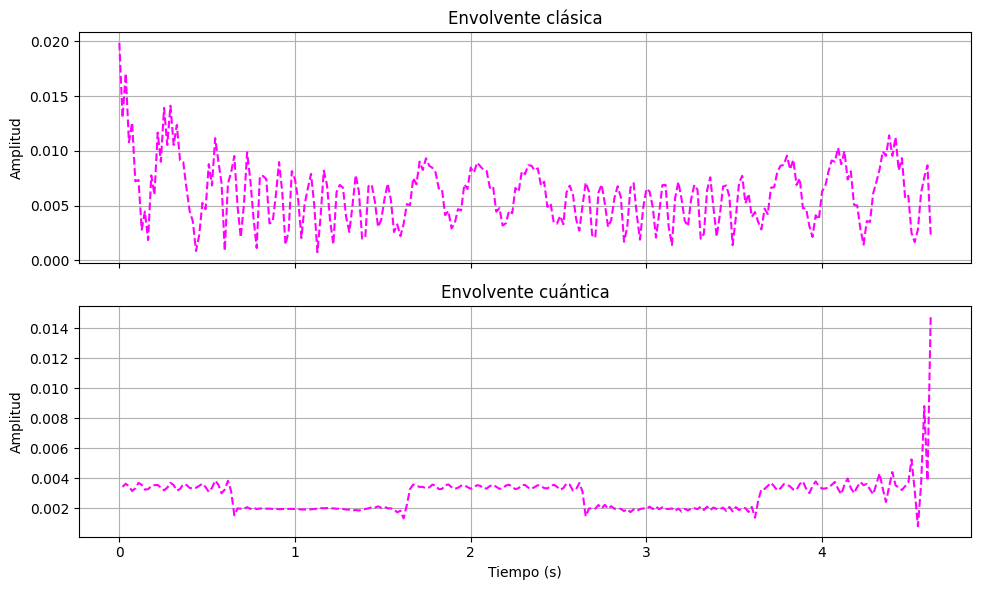

In [23]:
# Parámetros temporales
fs = 55  # Hz
num_samples = 255
dt = 1 / fs
t = np.arange(num_samples) * dt  # vector de tiempo

# Subplots
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

# Subplot 1: Cuántico
axs[0].plot(t,  # ajustamos tiempo
            input_sequence[0, 1:], 
            linestyle="dashed", color='magenta')
axs[0].set_title("Envolvente clásica")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)

# Subplot 2: Clásico
axs[1].plot(t[1:],  # ajustamos tiempo
            input_sequence_cuant2[0, 1:], 
            linestyle="dashed", color='magenta')
axs[1].set_title("Envolvente cuántica")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Amplitud")
axs[1].grid(True)

plt.tight_layout()
plt.show()

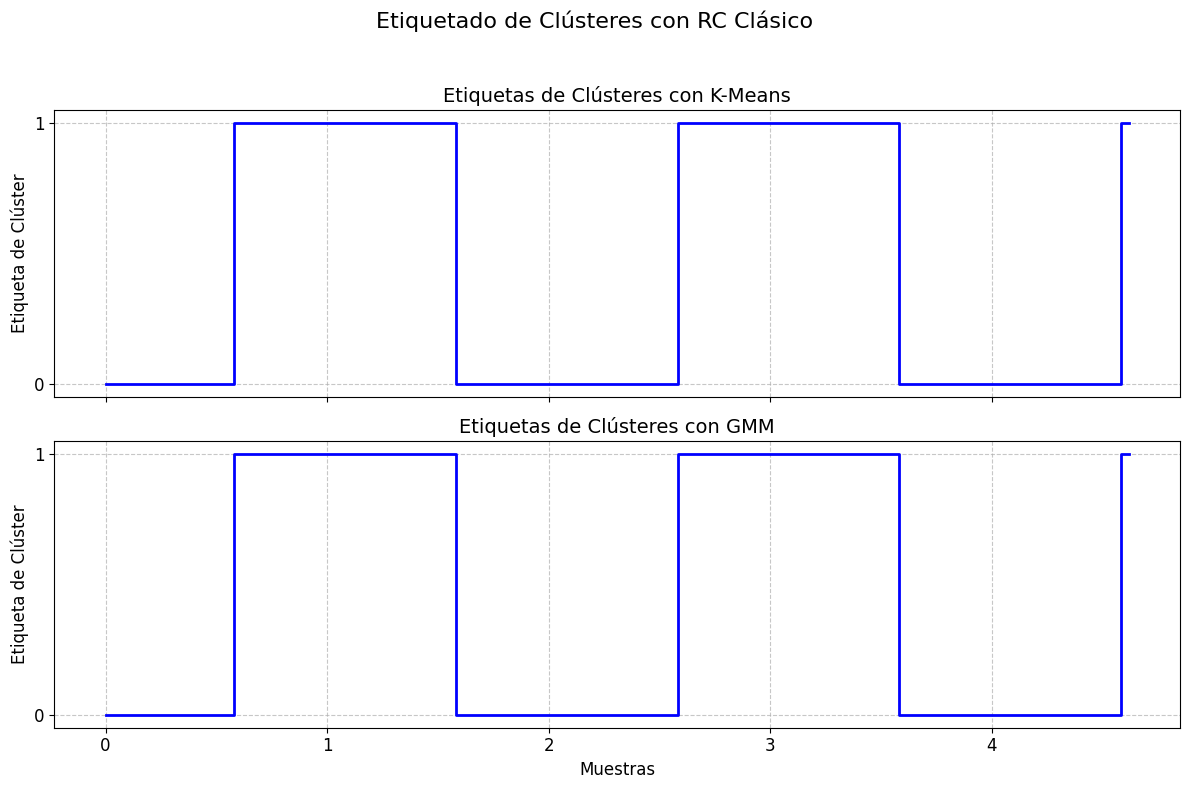

In [36]:
# Crear figura y subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Primer subplot: K-Means
axs[0].step(t, idx[1:], where='post', color='blue', linewidth=2)
axs[0].set_title('Etiquetas de Clústeres con K-Means', fontsize=14)
axs[0].set_ylabel('Etiqueta de Clúster', fontsize=12)
axs[0].set_yticks(np.arange(num_clusters))
axs[0].tick_params(axis='both', labelsize=12)
axs[0].grid(True, linestyle='--', alpha=0.7)

# Segundo subplot: GMM
axs[1].step(t, idx_gmm[1:], where='post', color='blue', linewidth=2)
axs[1].set_title('Etiquetas de Clústeres con GMM', fontsize=14)
axs[1].set_xlabel('Muestras', fontsize=12)
axs[1].set_ylabel('Etiqueta de Clúster', fontsize=12)
axs[1].set_yticks(np.arange(num_clusters))
axs[1].tick_params(axis='both', labelsize=12)
axs[1].grid(True, linestyle='--', alpha=0.7)

# Título global
fig.suptitle('Etiquetado de Clústeres con RC Clásico', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # deja espacio para el título global
plt.show()

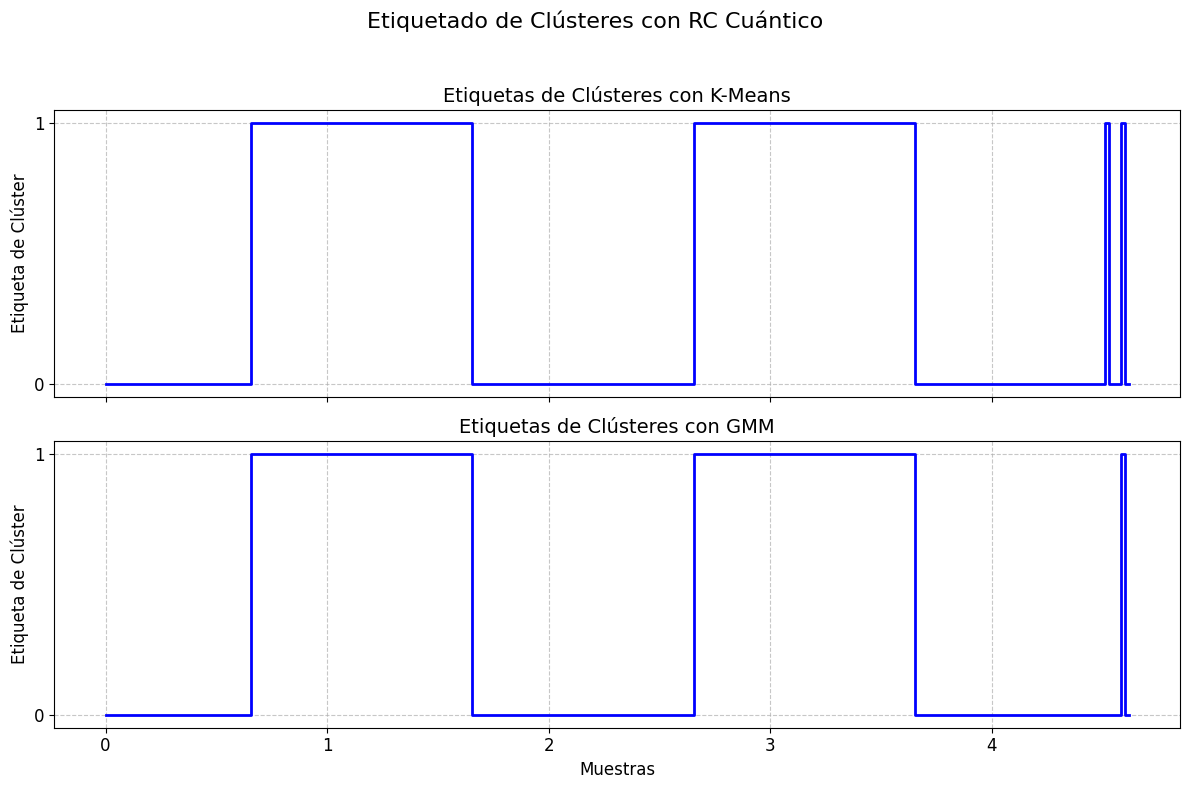

In [89]:
# Crear figura y subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Primer subplot: K-Means
axs[0].step(t, idx_cuant, where='post', color='blue', linewidth=2)
axs[0].set_title('Etiquetas de Clústeres con K-Means', fontsize=14)
axs[0].set_ylabel('Etiqueta de Clúster', fontsize=12)
axs[0].set_yticks(np.arange(num_clusters))
axs[0].tick_params(axis='both', labelsize=12)
axs[0].grid(True, linestyle='--', alpha=0.7)

# Segundo subplot: GMM
axs[1].step(t, idx_gmm_cuant, where='post', color='blue', linewidth=2)
axs[1].set_title('Etiquetas de Clústeres con GMM', fontsize=14)
axs[1].set_xlabel('Muestras', fontsize=12)
axs[1].set_ylabel('Etiqueta de Clúster', fontsize=12)
axs[1].set_yticks(np.arange(num_clusters))
axs[1].tick_params(axis='both', labelsize=12)
axs[1].grid(True, linestyle='--', alpha=0.7)

# Título global
fig.suptitle('Etiquetado de Clústeres con RC Cuántico', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # deja espacio para el título global
plt.show()